# ComexStat × Carriers: Valor Económico por Porto — 2023/2024
**Análise:** Posicionamento de carriers por valor de carga contentorizável  
**Fontes:** MDIC ComexStat EXP/IMP 2023-2024 · ANTAQ Atracação 2025 (escalas)  
**Filtros:** CO_VIA=4 (marítimo) | Excluídos granéis não contentorizados (NCM capítulos 10,12,23,25,26,27,72,73)

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE  = Path('../data')
CS    = BASE / '07_ComexStat'
PROC  = Path('../outputs/processed_data')
OUT   = Path('../outputs/figures')
PROC.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ── Constantes ─────────────────────────────────────────────────────────────────
EXCL_NCM2 = ('10','12','23','25','26','27','72','73')  # granéis não contentorizados

UF_PORTO = {
    'SP': 'Santos',        'PR': 'Paranaguá',    'SC': 'Itajaí',
    'RS': 'Rio Grande',    'RJ': 'Rio de Janeiro','CE': 'Pecém',
    'PE': 'Suape',         'PA': 'Vila do Conde',
}

# Mapeamento ANTAQ (porto_atracacao) → porto ComexStat
ANTAQ_PORTO_MAP = {
    'Santos'                                                  : 'Santos',
    'DP World Santos'                                         : 'Santos',
    'BTP - Brasil Terminal Portuário'                         : 'Santos',
    'Paranaguá'                                               : 'Paranaguá',
    'Itajaí'                                                  : 'Itajaí',
    'Porto Itapoá Terminais Portuários'                       : 'Itajaí',
    'Portonave - Terminais Portuários de Navegantes'          : 'Itajaí',
    'Rio Grande'                                              : 'Rio Grande',
    'Rio de Janeiro'                                          : 'Rio de Janeiro',
    'Itaguaí'                                                 : 'Rio de Janeiro',
    'Terminal Portuário do Pecém'                             : 'Pecém',
    'Suape'                                                   : 'Suape',
    'Vila do Conde'                                           : 'Vila do Conde',
    'Super Terminais Comércio e Indústria'                    : 'Outros Portos',
    'Fortaleza'                                               : 'Pecém',
}

PORTO_ORDER = ['Santos','Rio de Janeiro','Paranaguá','Itajaí','Rio Grande',
               'Pecém','Suape','Vila do Conde','Outros Portos']

CARRIER_COLORS = {
    'MAERSK':'#0043A8','MSC':'#D4002A','CMA CGM':'#E8821A','COSCO':'#EE2020',
    'EVERGREEN':'#2D8C2D','Hapag-Lloyd':'#FF6600','ONE':'#E60073','ZIM':'#00539B',
}

# Países (top 44 por VL_FOB combinado)
PAIS_MAP = {
    249:'EUA', 160:'China', 23:'Argentina', 275:'Países Baixos',
    149:'Chile', 767:'Singapura', 190:'Bélgica', 858:'Uruguai',
    386:'Japão', 493:'México', 628:'Peru', 161:'Colômbia',
    361:'Índia', 87:'Bolívia', 399:'Coreia do Sul', 375:'Itália',
    245:'Espanha', 232:'Alemanha', 455:'Malásia', 573:'Portugal',
    72:'Austrália', 764:'Suíça', 169:'Canadá', 351:'França',
    741:'Tailândia', 607:'Filipinas', 158:'Reino Unido', 63:'Áustria',
    827:'Vietname', 776:'Taiwan', 603:'Paquistão', 244:'Sri Lanka',
    589:'Noruega', 756:'Suécia', 383:'Israel', 355:'Irlanda',
    239:'Indonésia', 791:'Turquia', 267:'Dinamarca', 196:'Grécia',
    161:'Colômbia', 611:'Países Baixos', 455:'Malásia', 455:'Malásia',
}

NCM2_DESC = {
    '01':'Animais vivos','02':'Carnes','03':'Pescados','04':'Lácteos/Ovos',
    '05':'Prod. animais','06':'Plantas','07':'Legumes','08':'Frutas',
    '09':'Café/Chá','11':'Farinhas','13':'Gomas/Resinas','15':'Gorduras/Óleos',
    '16':'Prep. carne','17':'Açúcares','18':'Cacau','19':'Prep. cereais',
    '20':'Prep. frutas','21':'Prep. aliment.','22':'Bebidas','24':'Tabaco',
    '28':'Quím. inorgânicos','29':'Quím. orgânicos','30':'Farmacêuticos',
    '31':'Fertilizantes','32':'Tintas','33':'Cosméticos','34':'Sabões',
    '38':'Quím. diversos','39':'Plásticos','40':'Borracha','41':'Couros',
    '44':'Madeira','48':'Papel/Cartão','52':'Algodão','54':'Filamentos sint.',
    '61':'Vestuário malha','62':'Vestuário não-malha','63':'Têxteis confec.',
    '64':'Calçados','68':'Pedra/Gesso','69':'Cerâmica','70':'Vidros',
    '71':'Joias/Pedras preciosas','74':'Cobre','76':'Alumínio','82':'Ferramentas',
    '83':'Obras metal','84':'Máquinas/Mecânicos','85':'Máquinas elétricas',
    '87':'Veículos','88':'Aeronaves','89':'Embarcações','90':'Ópticos/Médicos',
    '93':'Armas','94':'Móveis','95':'Brinquedos','96':'Manufaturas','97':'Obras de arte',
}

print('Setup concluído.')
print(f'Portos mapeados (UF→Porto): {list(UF_PORTO.values())}')

Setup concluído.
Portos mapeados (UF→Porto): ['Santos', 'Paranaguá', 'Itajaí', 'Rio Grande', 'Rio de Janeiro', 'Pecém', 'Suape', 'Vila do Conde']


## 1. Pré-processamento ComexStat

In [2]:
def load_comexstat(fname, is_imp=False):
    """Carrega, filtra (CO_VIA=4, excl. bulk NCM) e mapeia UF→Porto."""
    cols = ['CO_ANO','CO_MES','CO_NCM','CO_PAIS','SG_UF_NCM','CO_VIA','KG_LIQUIDO','VL_FOB']
    if is_imp:
        cols.append('VL_FRETE')
    df = pd.read_csv(CS / fname, sep=';', encoding='latin1', usecols=cols,
                     dtype={'CO_NCM': str}, low_memory=False)
    # Passo 1: modal marítimo
    df = df[df['CO_VIA'] == 4].copy()
    # Passo 2: excluir granéis
    df['NCM2'] = df['CO_NCM'].str.zfill(8).str[:2]
    df = df[~df['NCM2'].isin(EXCL_NCM2)].copy()
    # Passo 3: mapear porto
    df['Porto']      = df['SG_UF_NCM'].map(UF_PORTO).fillna('Outros Portos')
    df['Pais_Nome']  = df['CO_PAIS'].map(PAIS_MAP).fillna('Outros')
    df['Sentido']    = 'IMP' if is_imp else 'EXP'
    if not is_imp:
        df['VL_FRETE'] = 0
    return df

print('Carregando datasets...')
exp23 = load_comexstat('EXP_2023.csv', is_imp=False)
exp24 = load_comexstat('EXP_2024.csv', is_imp=False)
imp23 = load_comexstat('IMP_2023.csv', is_imp=True)
imp24 = load_comexstat('IMP_2024.csv', is_imp=True)

for tag, df in [('EXP 2023',exp23),('EXP 2024',exp24),('IMP 2023',imp23),('IMP 2024',imp24)]:
    print(f'{tag}: {len(df):>9,} linhas | VL_FOB: USD {df["VL_FOB"].sum()/1e9:>7.2f}B')

# Dataset completo para análises cruzadas
full = pd.concat([exp23, exp24, imp23, imp24], ignore_index=True)
print(f'\nTotal combinado: {len(full):,} linhas')

# Cobertura do mapeamento UF→Porto
mapeados_pct_exp = exp24['SG_UF_NCM'].isin(UF_PORTO.keys()).mean() * 100
mapeados_pct_imp = imp24['SG_UF_NCM'].isin(UF_PORTO.keys()).mean() * 100
print(f'\n⚠️  Cobertura mapeamento UF→Porto (2024):')
print(f'   EXP: {mapeados_pct_exp:.1f}% das linhas | IMP: {mapeados_pct_imp:.1f}%')
print(f'   "Outros Portos" inclui MG, BA, GO, MT, AM, MA e outros estados')
print(f'   com múltiplos portos activos — não atribuíveis a um único terminal.')

Carregando datasets...


EXP 2023:   407,874 linhas | VL_FOB: USD   13.29B
EXP 2024:   415,317 linhas | VL_FOB: USD   14.81B
IMP 2023:   919,216 linhas | VL_FOB: USD   45.35B
IMP 2024:   993,341 linhas | VL_FOB: USD   51.97B

Total combinado: 2,735,748 linhas



⚠️  Cobertura mapeamento UF→Porto (2024):
   EXP: 88.0% das linhas | IMP: 76.6%
   "Outros Portos" inclui MG, BA, GO, MT, AM, MA e outros estados
   com múltiplos portos activos — não atribuíveis a um único terminal.


## 2. Análise Parte 1 — Valor por Porto (2023–2024)

### 2.1 VL_FOB, KG e Ratio por Porto

In [3]:
def tabela_porto_ano(df_list, labels, sentido):
    rows = []
    for df, label in zip(df_list, labels):
        agg = df.groupby('Porto').agg(
            VL_FOB=('VL_FOB','sum'), KG=('KG_LIQUIDO','sum')
        ).reset_index()
        agg['Ano']     = label
        agg['Sentido'] = sentido
        agg['USD_kg']  = agg['VL_FOB'] / agg['KG'].replace(0, np.nan)
        rows.append(agg)
    return pd.concat(rows, ignore_index=True)

porto_exp = tabela_porto_ano([exp23, exp24], [2023, 2024], 'EXP')
porto_imp = tabela_porto_ano([imp23, imp24], [2023, 2024], 'IMP')
porto_all = pd.concat([porto_exp, porto_imp], ignore_index=True)

# Pivot para visualização
pivot_fob = porto_all.pivot_table(
    index='Porto', columns=['Sentido','Ano'], values='VL_FOB', aggfunc='sum'
).reindex(PORTO_ORDER)
pivot_fob.columns = [f'{s}_{a}' for s, a in pivot_fob.columns]

# Crescimento 2023→2024
pivot_fob['EXP_cresc_%'] = ((pivot_fob['EXP_2024'] - pivot_fob['EXP_2023']) / pivot_fob['EXP_2023'] * 100).round(1)
pivot_fob['IMP_cresc_%'] = ((pivot_fob['IMP_2024'] - pivot_fob['IMP_2023']) / pivot_fob['IMP_2023'] * 100).round(1)

# USD/kg 2024
pivot_fob['USD_kg_EXP_24'] = (
    porto_exp[porto_exp['Ano']==2024].set_index('Porto')['USD_kg']
    .reindex(PORTO_ORDER)
).values
pivot_fob['USD_kg_IMP_24'] = (
    porto_imp[porto_imp['Ano']==2024].set_index('Porto')['USD_kg']
    .reindex(PORTO_ORDER)
).values

print('=== VL_FOB por Porto (USD B) + Crescimento + USD/kg ===')
display_df = pivot_fob.copy()
for c in ['EXP_2023','EXP_2024','IMP_2023','IMP_2024']:
    display_df[c] = (display_df[c] / 1e9).round(2)
print(display_df.round(2).to_string())

=== VL_FOB por Porto (USD B) + Crescimento + USD/kg ===
                EXP_2023  EXP_2024  IMP_2023  IMP_2024  EXP_cresc_%  IMP_cresc_%  USD_kg_EXP_24  USD_kg_IMP_24
Porto                                                                                                         
Santos              6.03      7.04     19.07     21.16         16.8         11.0          62.20         159.14
Rio de Janeiro      1.01      0.86      9.32     11.35        -15.1         21.7          71.46         708.02
Paranaguá           0.48      0.51      1.42      1.51          6.1          6.4          22.11         114.84
Itajaí              0.31      0.34      1.87      2.45         12.0         31.2          17.62         125.04
Rio Grande          0.72      0.63      0.62      0.64        -11.8          3.5          34.56          99.59
Pecém               0.04      0.03      0.10      0.08        -11.7        -19.2          11.46          78.39
Suape               0.03      0.04      0.33      0.31  

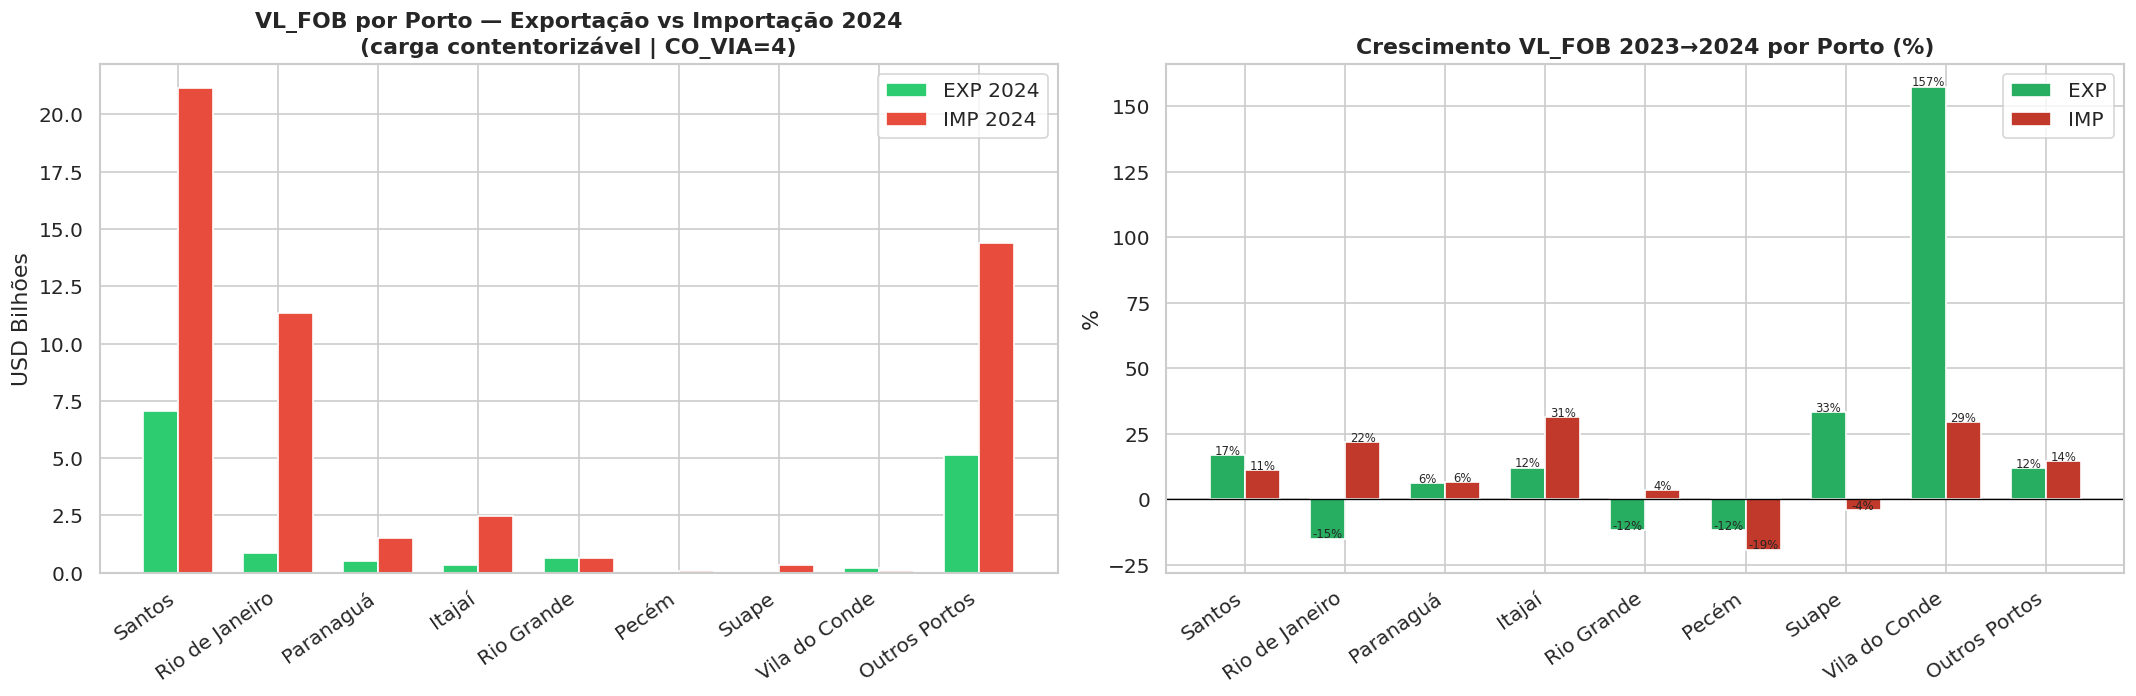

In [4]:
# Gráfico: VL_FOB por porto (EXP + IMP 2024)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

portos_plot = [p for p in PORTO_ORDER if p in pivot_fob.index]
x = np.arange(len(portos_plot))
w = 0.35

exp_vals = pivot_fob.loc[portos_plot, 'EXP_2024'].fillna(0) / 1e9
imp_vals = pivot_fob.loc[portos_plot, 'IMP_2024'].fillna(0) / 1e9

axes[0].bar(x - w/2, exp_vals, width=w, label='EXP 2024', color='#2ecc71', edgecolor='white')
axes[0].bar(x + w/2, imp_vals, width=w, label='IMP 2024', color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(portos_plot, rotation=35, ha='right')
axes[0].set_title('VL_FOB por Porto — Exportação vs Importação 2024\n(carga contentorizável | CO_VIA=4)', fontweight='bold')
axes[0].set_ylabel('USD Bilhões')
axes[0].legend()

# Crescimento 2023→2024
cresc_exp = pivot_fob.loc[portos_plot, 'EXP_cresc_%'].fillna(0)
cresc_imp = pivot_fob.loc[portos_plot, 'IMP_cresc_%'].fillna(0)
axes[1].bar(x - w/2, cresc_exp, width=w, label='EXP', color='#27ae60', edgecolor='white')
axes[1].bar(x + w/2, cresc_imp, width=w, label='IMP', color='#c0392b', edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(portos_plot, rotation=35, ha='right')
axes[1].set_title('Crescimento VL_FOB 2023→2024 por Porto (%)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend()
for xi, (ve, vi) in enumerate(zip(cresc_exp, cresc_imp)):
    axes[1].text(xi - w/2, ve + 0.3, f'{ve:.0f}%', ha='center', fontsize=7)
    axes[1].text(xi + w/2, vi + 0.3, f'{vi:.0f}%', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(OUT / 'nb11_01_fob_porto.png', bbox_inches='tight')
plt.show()

### 2.2 USD/kg por Porto — Densidade de Valor da Carga

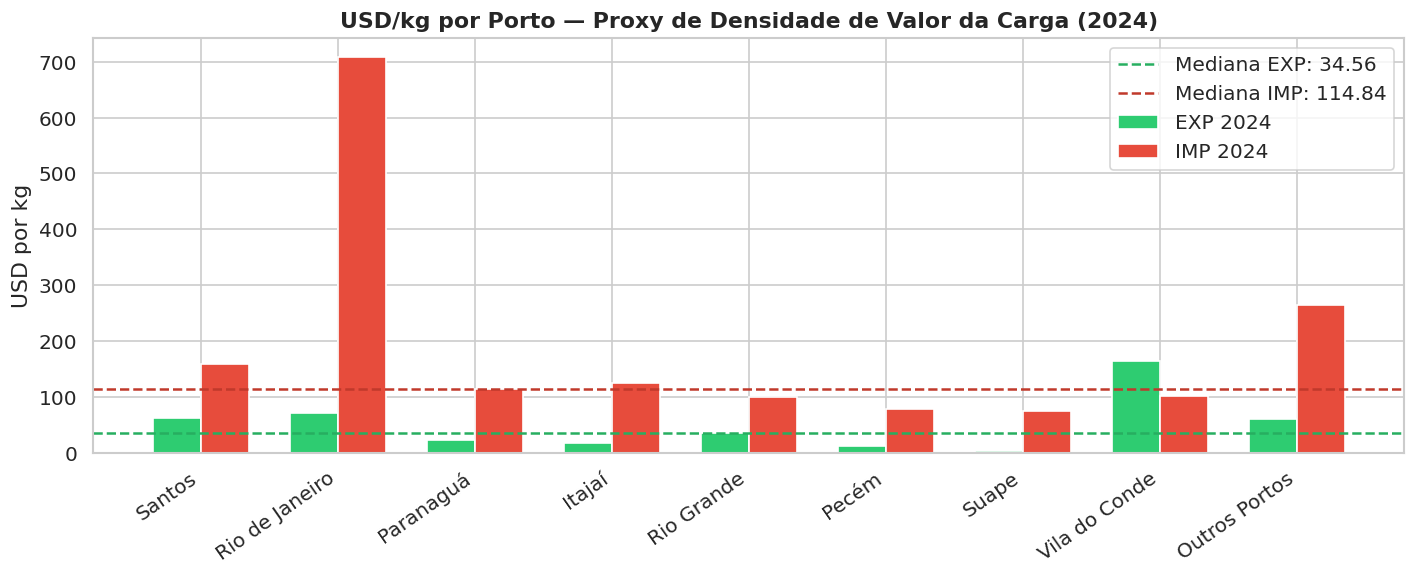

USD/kg por Porto (2024):
                   EXP     IMP
Porto                         
Santos           62.20  159.14
Rio de Janeiro   71.46  708.02
Paranaguá        22.11  114.84
Itajaí           17.62  125.04
Rio Grande       34.56   99.59
Pecém            11.46   78.39
Suape             3.06   74.57
Vila do Conde   163.39  102.21
Outros Portos    60.55  263.54


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

usd_exp = pivot_fob.loc[portos_plot, 'USD_kg_EXP_24'].fillna(0)
usd_imp = pivot_fob.loc[portos_plot, 'USD_kg_IMP_24'].fillna(0)

ax.bar(x - w/2, usd_exp, width=w, label='EXP 2024', color='#2ecc71', edgecolor='white')
ax.bar(x + w/2, usd_imp, width=w, label='IMP 2024', color='#e74c3c', edgecolor='white')
ax.axhline(usd_exp.median(), color='#27ae60', linestyle='--', linewidth=1.5,
           label=f'Mediana EXP: {usd_exp.median():.2f}')
ax.axhline(usd_imp.median(), color='#c0392b', linestyle='--', linewidth=1.5,
           label=f'Mediana IMP: {usd_imp.median():.2f}')
ax.set_xticks(x)
ax.set_xticklabels(portos_plot, rotation=35, ha='right')
ax.set_title('USD/kg por Porto — Proxy de Densidade de Valor da Carga (2024)', fontweight='bold')
ax.set_ylabel('USD por kg')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'nb11_02_usdkg_porto.png', bbox_inches='tight')
plt.show()

print('USD/kg por Porto (2024):')
print(pd.DataFrame({'EXP': usd_exp.round(2), 'IMP': usd_imp.round(2)}).to_string())

### 2.3 Top 5 Países Destino por Porto (EXP 2024)

In [6]:
print('Top 5 países destino por porto — EXP 2024 (VL_FOB USD M):')
print('=' * 65)
for porto in PORTO_ORDER:
    sub = exp24[exp24['Porto'] == porto]
    if len(sub) == 0:
        continue
    top5 = sub.groupby('Pais_Nome')['VL_FOB'].sum().sort_values(ascending=False).head(5)
    tot  = sub['VL_FOB'].sum()
    print(f'\n{porto} (Total: USD {tot/1e6:.0f}M):')
    for pais, vl in top5.items():
        print(f'  {pais:<22} USD {vl/1e6:>7.0f}M  ({vl/tot*100:.1f}%)')

Top 5 países destino por porto — EXP 2024 (VL_FOB USD M):

Santos (Total: USD 7041M):
  EUA                    USD    3213M  (45.6%)
  Outros                 USD     458M  (6.5%)
  Argentina              USD     319M  (4.5%)
  Canadá                 USD     284M  (4.0%)
  México                 USD     274M  (3.9%)

Rio de Janeiro (Total: USD 861M):
  EUA                    USD     380M  (44.2%)
  Países Baixos          USD     114M  (13.3%)
  Outros                 USD      83M  (9.7%)
  Peru                   USD      38M  (4.4%)
  México                 USD      30M  (3.5%)

Paranaguá (Total: USD 511M):
  EUA                    USD     115M  (22.4%)
  Outros                 USD      72M  (14.0%)
  Singapura              USD      41M  (8.1%)
  México                 USD      38M  (7.4%)
  Áustria                USD      29M  (5.7%)

Itajaí (Total: USD 343M):
  EUA                    USD      64M  (18.7%)
  Outros                 USD      44M  (12.9%)
  México                 USD     


Pecém (Total: USD 33M):
  EUA                    USD      10M  (30.4%)
  Outros                 USD       5M  (13.7%)
  Indonésia              USD       4M  (12.8%)
  Reino Unido            USD       3M  (7.9%)
  Filipinas              USD       2M  (4.6%)



Suape (Total: USD 37M):
  Filipinas              USD      14M  (37.8%)
  Bélgica                USD       7M  (18.7%)
  EUA                    USD       7M  (18.0%)
  Países Baixos          USD       1M  (2.5%)
  Outros                 USD       1M  (2.4%)

Vila do Conde (Total: USD 198M):
  Singapura              USD      89M  (45.0%)
  Chile                  USD      34M  (17.2%)
  EUA                    USD      33M  (16.5%)
  França                 USD      28M  (14.1%)
  Outros                 USD       6M  (3.0%)

Outros Portos (Total: USD 5149M):
  Chile                  USD    1850M  (35.9%)
  Singapura              USD     870M  (16.9%)
  Peru                   USD     601M  (11.7%)
  EUA                    USD     559M  (10.9%)
  Argentina              USD     188M  (3.6%)


### 2.4 Top 5 NCM2 por Porto (EXP 2024)

In [7]:
print('Top 5 capítulos NCM por porto — EXP 2024 (VL_FOB USD M):')
print('=' * 65)
for porto in PORTO_ORDER:
    sub = exp24[exp24['Porto'] == porto]
    if len(sub) == 0:
        continue
    top5 = sub.groupby('NCM2')['VL_FOB'].sum().sort_values(ascending=False).head(5)
    tot  = sub['VL_FOB'].sum()
    print(f'\n{porto} (Total: USD {tot/1e6:.0f}M):')
    for ncm, vl in top5.items():
        desc = NCM2_DESC.get(ncm, ncm)
        print(f'  Cap.{ncm} {desc:<28} USD {vl/1e6:>7.0f}M  ({vl/tot*100:.1f}%)')

Top 5 capítulos NCM por porto — EXP 2024 (VL_FOB USD M):

Santos (Total: USD 7041M):
  Cap.88 Aeronaves                    USD    2897M  (41.2%)
  Cap.84 Máquinas/Mecânicos           USD     862M  (12.2%)
  Cap.85 Máquinas elétricas           USD     567M  (8.1%)
  Cap.90 Ópticos/Médicos              USD     459M  (6.5%)
  Cap.30 Farmacêuticos                USD     446M  (6.3%)

Rio de Janeiro (Total: USD 861M):
  Cap.84 Máquinas/Mecânicos           USD     460M  (53.4%)
  Cap.30 Farmacêuticos                USD      65M  (7.5%)
  Cap.90 Ópticos/Médicos              USD      61M  (7.1%)
  Cap.85 Máquinas elétricas           USD      61M  (7.0%)
  Cap.88 Aeronaves                    USD      48M  (5.6%)

Paranaguá (Total: USD 511M):
  Cap.85 Máquinas elétricas           USD     105M  (20.5%)
  Cap.90 Ópticos/Médicos              USD      90M  (17.5%)
  Cap.84 Máquinas/Mecânicos           USD      70M  (13.7%)
  Cap.30 Farmacêuticos                USD      40M  (7.9%)
  Cap.04 Lácteos/O


Itajaí (Total: USD 343M):
  Cap.84 Máquinas/Mecânicos           USD      93M  (27.1%)
  Cap.85 Máquinas elétricas           USD      88M  (25.7%)
  Cap.90 Ópticos/Médicos              USD      32M  (9.3%)
  Cap.04 Lácteos/Ovos                 USD      20M  (5.9%)
  Cap.61 Vestuário malha              USD       9M  (2.7%)



Rio Grande (Total: USD 633M):
  Cap.93 Armas                        USD     173M  (27.3%)
  Cap.64 Calçados                     USD     132M  (20.8%)
  Cap.85 Máquinas elétricas           USD      66M  (10.5%)
  Cap.84 Máquinas/Mecânicos           USD      42M  (6.6%)
  Cap.41 Couros                       USD      37M  (5.8%)

Pecém (Total: USD 33M):
  Cap.64 Calçados                     USD      16M  (47.5%)
  Cap.03 Pescados                     USD       3M  (8.0%)
  Cap.21 Prep. aliment.               USD       2M  (5.9%)
  Cap.33 Cosméticos                   USD       2M  (5.4%)
  Cap.08 Frutas                       USD       1M  (4.5%)



Suape (Total: USD 37M):
  Cap.08 Frutas                       USD      24M  (64.3%)
  Cap.03 Pescados                     USD       5M  (14.5%)
  Cap.90 Ópticos/Médicos              USD       1M  (4.1%)
  Cap.84 Máquinas/Mecânicos           USD       1M  (2.5%)
  Cap.21 Prep. aliment.               USD       1M  (2.5%)

Vila do Conde (Total: USD 198M):
  Cap.71 Joias/Pedras preciosas       USD     158M  (79.6%)
  Cap.03 Pescados                     USD      21M  (10.7%)
  Cap.05 Prod. animais                USD       9M  (4.7%)
  Cap.11 Farinhas                     USD       5M  (2.7%)
  Cap.08 Frutas                       USD       2M  (0.9%)

Outros Portos (Total: USD 5149M):
  Cap.71 Joias/Pedras preciosas       USD    3783M  (73.5%)
  Cap.05 Prod. animais                USD     182M  (3.5%)
  Cap.84 Máquinas/Mecânicos           USD     182M  (3.5%)
  Cap.90 Ópticos/Médicos              USD     167M  (3.2%)
  Cap.85 Máquinas elétricas           USD     161M  (3.1%)


## 3. Análise Parte 2 — Valor por Corredor

### 3.1 Top 10 Corredores Porto × País × Sentido

In [8]:
corridors = (
    full[full['CO_ANO'] == 2024]
    .groupby(['Porto','Pais_Nome','Sentido'])['VL_FOB']
    .sum()
    .reset_index()
    .sort_values('VL_FOB', ascending=False)
)
corridors['VL_FOB_B'] = (corridors['VL_FOB'] / 1e9).round(2)

print('Top 20 corredores por VL_FOB — 2024 (USD B):')
print(corridors.head(20)[['Porto','Pais_Nome','Sentido','VL_FOB_B']].to_string(index=False))

Top 20 corredores por VL_FOB — 2024 (USD B):
         Porto     Pais_Nome Sentido  VL_FOB_B
Rio de Janeiro           EUA     IMP      6.71
        Santos           EUA     IMP      5.20
        Santos         China     IMP      3.22
        Santos           EUA     EXP      3.21
 Outros Portos           EUA     IMP      2.67
 Outros Portos         China     IMP      2.46
 Outros Portos         Chile     EXP      1.85
        Santos     Argentina     IMP      1.58
Rio de Janeiro Países Baixos     IMP      1.58
 Outros Portos     Argentina     IMP      1.26
        Santos Países Baixos     IMP      1.26
 Outros Portos       Uruguai     IMP      1.11
        Santos       Bélgica     IMP      1.00
        Santos     Singapura     IMP      0.98
 Outros Portos     Singapura     EXP      0.87
 Outros Portos       Bélgica     IMP      0.82
 Outros Portos        Itália     IMP      0.81
 Outros Portos      Colômbia     IMP      0.73
        Santos         Japão     IMP      0.72
        Santos 

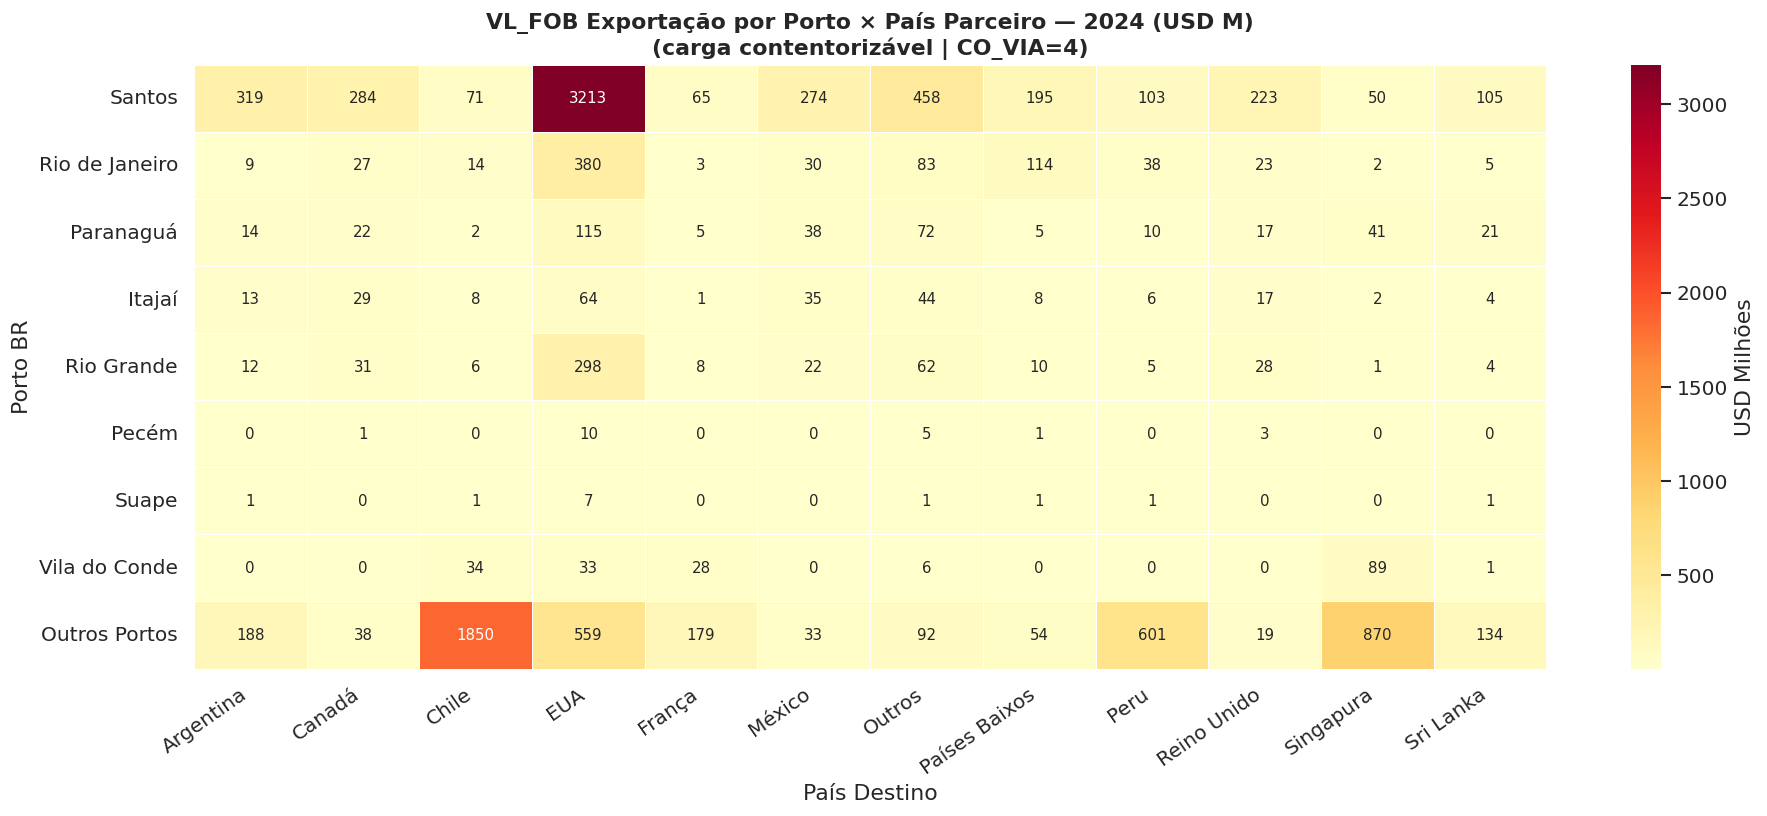

In [9]:
# Heatmap: porto × país (VL_FOB EXP 2024, top parceiros)
top_paises = (
    exp24.groupby('Pais_Nome')['VL_FOB'].sum()
    .sort_values(ascending=False)
    .head(12)
    .index.tolist()
)

heat_exp = (
    exp24[exp24['Pais_Nome'].isin(top_paises)]
    .groupby(['Porto','Pais_Nome'])['VL_FOB']
    .sum()
    .unstack(fill_value=0)
    .reindex(PORTO_ORDER)
    .div(1e6)  # USD M
)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(heat_exp.fillna(0), annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'USD Milhões'},
            annot_kws={'size': 9})
ax.set_title('VL_FOB Exportação por Porto × País Parceiro — 2024 (USD M)\n'
             '(carga contentorizável | CO_VIA=4)', fontweight='bold')
ax.set_xlabel('País Destino')
ax.set_ylabel('Porto BR')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(OUT / 'nb11_03_heatmap_porto_pais_exp.png', bbox_inches='tight')
plt.show()

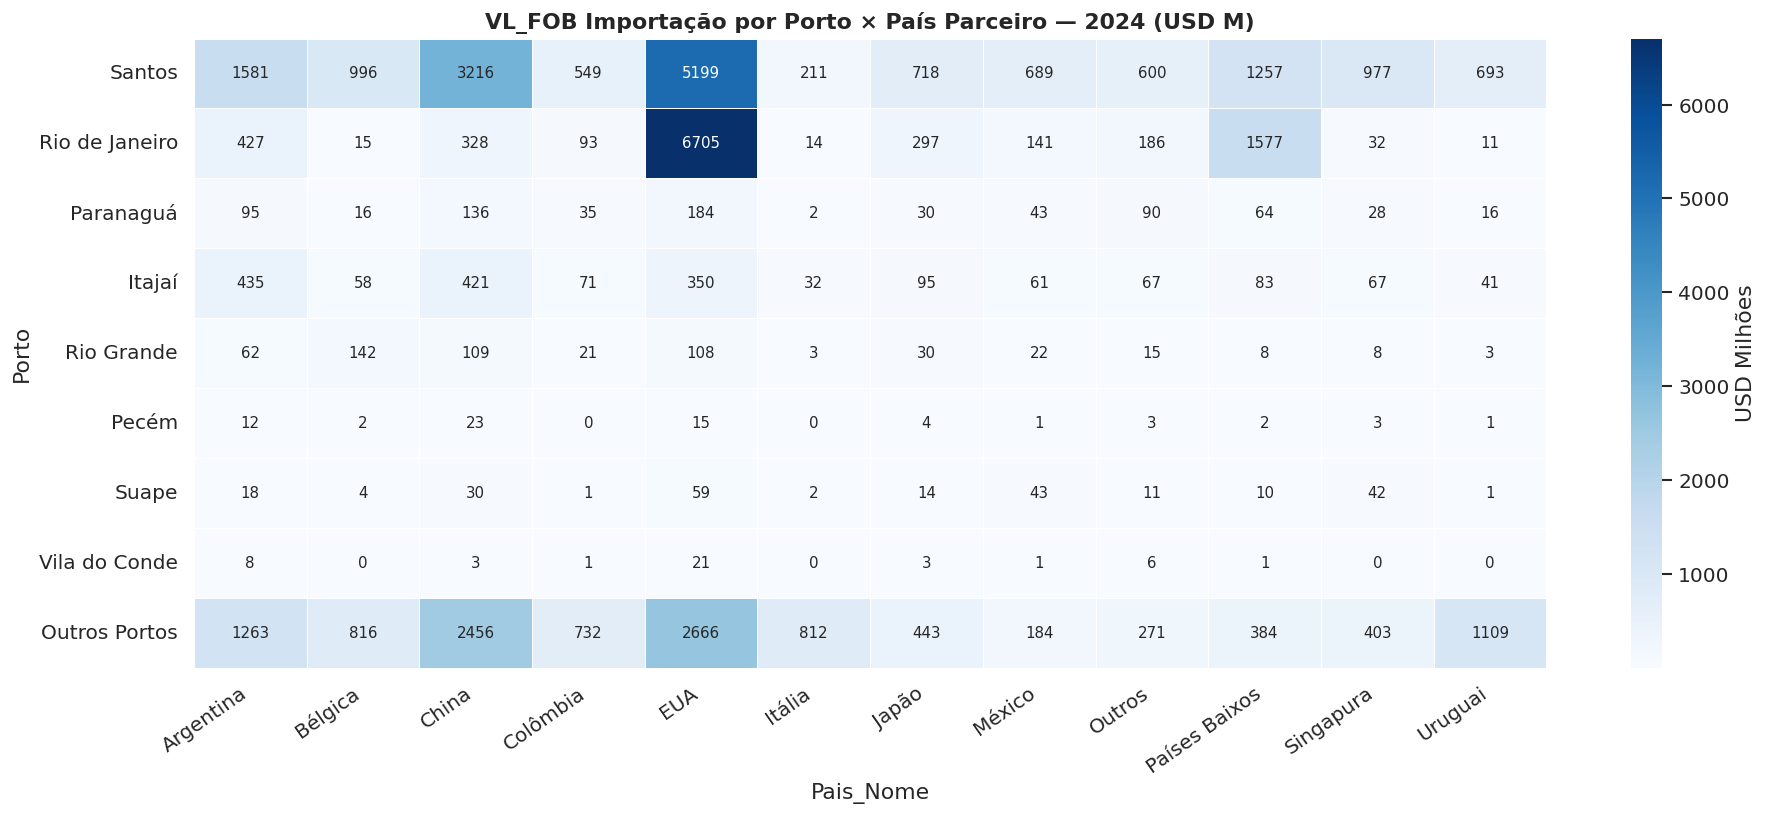

In [10]:
# Heatmap importação
top_paises_imp = (
    imp24.groupby('Pais_Nome')['VL_FOB'].sum()
    .sort_values(ascending=False).head(12).index.tolist()
)
heat_imp = (
    imp24[imp24['Pais_Nome'].isin(top_paises_imp)]
    .groupby(['Porto','Pais_Nome'])['VL_FOB']
    .sum().unstack(fill_value=0)
    .reindex(PORTO_ORDER).div(1e6)
)
fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(heat_imp.fillna(0), annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'USD Milhões'},
            annot_kws={'size': 9})
ax.set_title('VL_FOB Importação por Porto × País Parceiro — 2024 (USD M)', fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(OUT / 'nb11_04_heatmap_porto_pais_imp.png', bbox_inches='tight')
plt.show()

### 3.2 China como Parceiro — % VL_FOB por Porto

China como parceiro — % VL_FOB por Porto (2024):
Sentido         EXP   IMP
Porto                    
Itajaí          2.5  17.2
Outros Portos   1.0  17.1
Paranaguá       1.5   9.0
Pecém           2.3  27.6
Rio Grande      2.7  17.0
Rio de Janeiro  0.7   2.9
Santos          0.8  15.2
Suape           0.3   9.5
Vila do Conde   1.1   5.5


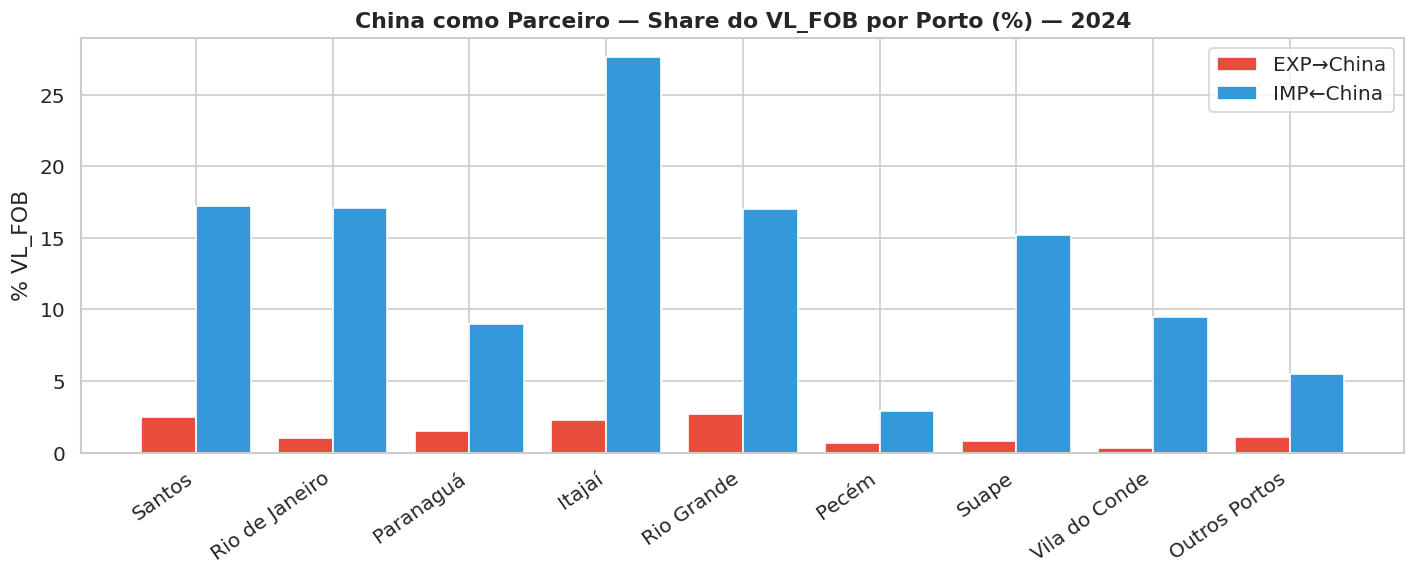

In [11]:
china_code = 160

china_share = []
for porto in PORTO_ORDER:
    for sentido, df_s in [('EXP', exp24), ('IMP', imp24)]:
        sub = df_s[df_s['Porto'] == porto]
        tot = sub['VL_FOB'].sum()
        china_vl = sub[sub['CO_PAIS'] == china_code]['VL_FOB'].sum()
        china_share.append({
            'Porto': porto, 'Sentido': sentido,
            'VL_FOB_Total_M': round(tot / 1e6, 1),
            'China_M': round(china_vl / 1e6, 1),
            'China_%': round(china_vl / tot * 100, 1) if tot > 0 else 0
        })

china_df = pd.DataFrame(china_share)
pivot_china = china_df.pivot(index='Porto', columns='Sentido', values='China_%')
print('China como parceiro — % VL_FOB por Porto (2024):')
print(pivot_china.round(1).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(PORTO_ORDER))
exp_china = pivot_china['EXP'].fillna(0)
imp_china = pivot_china['IMP'].fillna(0)
ax.bar(x - 0.2, exp_china, 0.4, label='EXP→China', color='#e74c3c', edgecolor='white')
ax.bar(x + 0.2, imp_china, 0.4, label='IMP←China', color='#3498db', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(PORTO_ORDER, rotation=35, ha='right')
ax.set_title('China como Parceiro — Share do VL_FOB por Porto (%) — 2024', fontweight='bold')
ax.set_ylabel('% VL_FOB')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'nb11_05_china_share.png', bbox_inches='tight')
plt.show()

### 3.3 Matriz 2×2 — Alto Valor/kg vs Alto Volume por Porto

Matriz 2×2 por Porto (EXP+IMP 2024):
         Porto  VL_FOB_B  USD_kg                  Quadrante
        Santos     28.20  114.56   Alto valor + Alto volume
 Outros Portos     19.54  139.94   Alto valor + Alto volume
Rio de Janeiro     12.21  434.87   Alto valor + Alto volume
        Itajaí      2.79   71.54   Alto valor + Alto volume
     Paranaguá      2.02   55.71  Baixo valor + Alto volume
    Rio Grande      1.28   51.52 Baixo valor + Baixo volume
         Suape      0.35   21.66 Baixo valor + Baixo volume
 Vila do Conde      0.26  143.61  Alto valor + Baixo volume
         Pecém      0.12   29.39 Baixo valor + Baixo volume


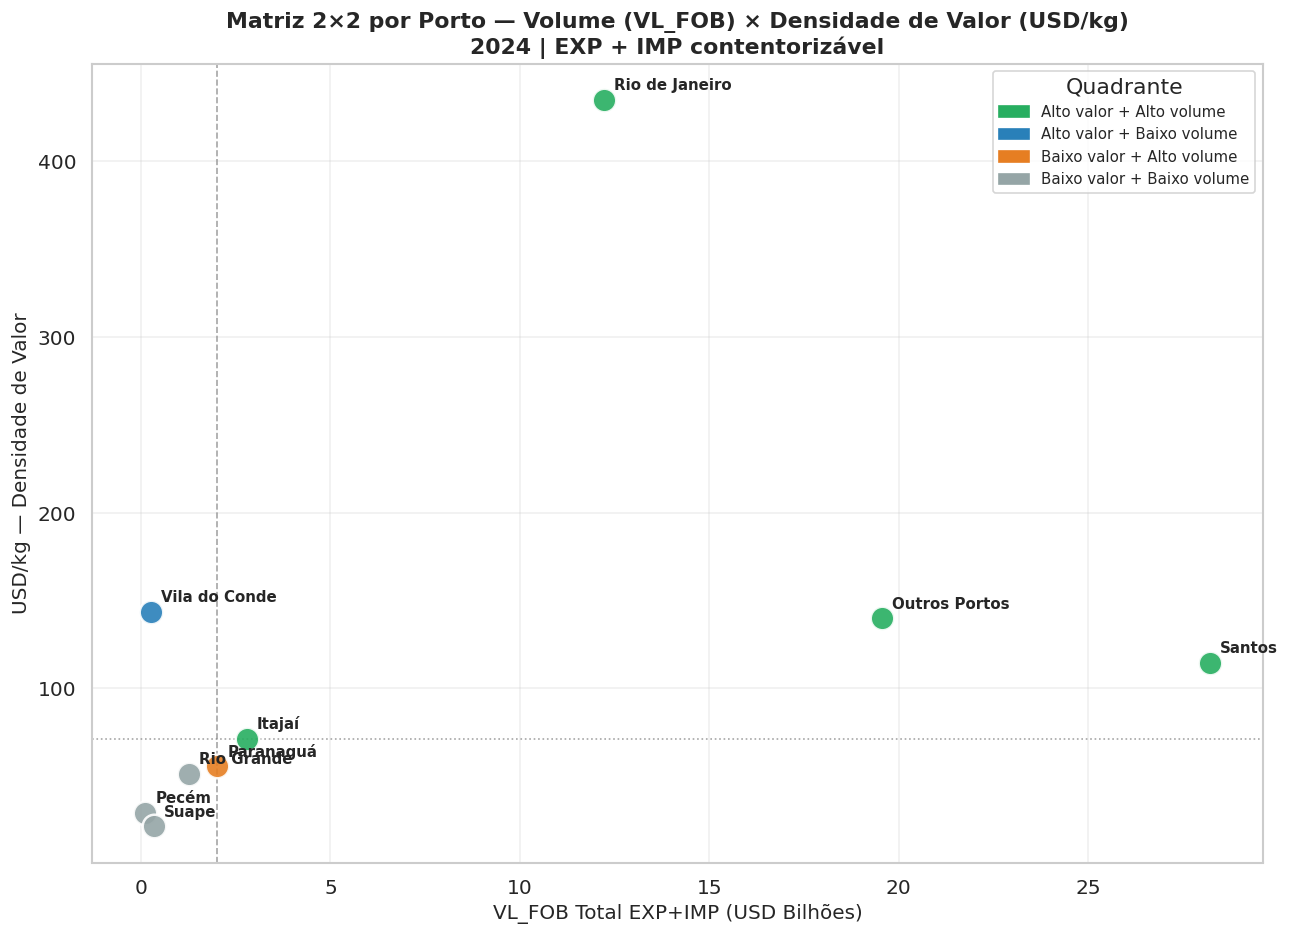

In [12]:
# Por porto: VL_FOB total (EXP+IMP 2024) e USD/kg médio
porto_2d = (
    full[full['CO_ANO'] == 2024]
    .groupby('Porto')
    .agg(VL_FOB_B=('VL_FOB', lambda x: x.sum()/1e9),
         KG_B=('KG_LIQUIDO', lambda x: x.sum()/1e9),
         USD_kg=('VL_FOB', lambda x: x.sum() / full.loc[x.index,'KG_LIQUIDO'].replace(0,np.nan).sum()))
    .reset_index()
)

# Recalcular USD/kg correctamente
agg2d = full[full['CO_ANO']==2024].groupby('Porto').agg(
    VL_FOB=('VL_FOB','sum'), KG=('KG_LIQUIDO','sum')
).reset_index()
agg2d['VL_FOB_B'] = agg2d['VL_FOB'] / 1e9
agg2d['USD_kg']   = agg2d['VL_FOB'] / agg2d['KG'].replace(0, np.nan)
agg2d = agg2d[agg2d['Porto'].isin(PORTO_ORDER)]

med_vl  = agg2d['VL_FOB_B'].median()
med_ukg = agg2d['USD_kg'].median()

def quadrant(row):
    hi_val = row['USD_kg'] >= med_ukg
    hi_vol = row['VL_FOB_B'] >= med_vl
    if hi_val and hi_vol:   return 'Alto valor + Alto volume'
    if hi_val and not hi_vol: return 'Alto valor + Baixo volume'
    if not hi_val and hi_vol: return 'Baixo valor + Alto volume'
    return 'Baixo valor + Baixo volume'

agg2d['Quadrante'] = agg2d.apply(quadrant, axis=1)

print('Matriz 2×2 por Porto (EXP+IMP 2024):')
print(agg2d[['Porto','VL_FOB_B','USD_kg','Quadrante']].sort_values('VL_FOB_B', ascending=False).round(2).to_string(index=False))

Q_COLORS = {
    'Alto valor + Alto volume'   : '#27ae60',
    'Alto valor + Baixo volume'  : '#2980b9',
    'Baixo valor + Alto volume'  : '#e67e22',
    'Baixo valor + Baixo volume' : '#95a5a6',
}

fig, ax = plt.subplots(figsize=(11, 8))
for _, row in agg2d.iterrows():
    c = Q_COLORS.get(row['Quadrante'], '#888')
    ax.scatter(row['VL_FOB_B'], row['USD_kg'], s=200, color=c, alpha=0.9,
               edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(row['Porto'], xy=(row['VL_FOB_B'], row['USD_kg']),
                xytext=(6, 6), textcoords='offset points', fontsize=9, fontweight='bold')

ax.axvline(med_vl,  color='gray', linestyle='--', linewidth=1, alpha=0.7, label=f'Mediana VL_FOB: {med_vl:.1f}B')
ax.axhline(med_ukg, color='gray', linestyle=':',  linewidth=1, alpha=0.7, label=f'Mediana USD/kg: {med_ukg:.2f}')

handles = [mpatches.Patch(color=c, label=q) for q, c in Q_COLORS.items()]
ax.legend(handles=handles, loc='upper right', fontsize=9, title='Quadrante')
ax.set_xlabel('VL_FOB Total EXP+IMP (USD Bilhões)', fontsize=12)
ax.set_ylabel('USD/kg — Densidade de Valor', fontsize=12)
ax.set_title('Matriz 2×2 por Porto — Volume (VL_FOB) × Densidade de Valor (USD/kg)\n2024 | EXP + IMP contentorizável', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'nb11_06_matriz_2x2_porto.png', bbox_inches='tight')
plt.show()

## 4. Análise Parte 3 — Posicionamento dos Carriers

### 4.1 Construção do VL_FOB Addressable por Carrier

In [13]:
# Carrier × Porto (escalas 2025)
pbi = pd.read_csv(PROC / 'presenca_operacional_carrier_2025_pbi.csv')

# Mapear porto ANTAQ → porto ComexStat
carrier_porto_raw = (
    pbi[pbi['container_identified'] == True]
    .groupby(['SHIPPING LINE', 'Porto Atracação'])
    .size()
    .reset_index(name='Escalas')
)
carrier_porto_raw['Porto_CS'] = (
    carrier_porto_raw['Porto Atracação']
    .map(ANTAQ_PORTO_MAP)
    .fillna('Outros Portos')
)

# Agregar por carrier × porto_CS
carrier_porto = (
    carrier_porto_raw.groupby(['SHIPPING LINE', 'Porto_CS'])['Escalas']
    .sum()
    .reset_index()
)

# VL_FOB por porto (EXP+IMP 2024)
porto_vlfob = (
    full[full['CO_ANO'] == 2024]
    .groupby('Porto')['VL_FOB']
    .sum()
    .rename('VL_FOB_Porto')
)

# Join
carrier_porto = carrier_porto.join(porto_vlfob, on='Porto_CS')
carrier_porto['VL_FOB_Porto'] = carrier_porto['VL_FOB_Porto'].fillna(0)
carrier_porto['VL_FOB_Weighted'] = carrier_porto['Escalas'] * carrier_porto['VL_FOB_Porto']

# Total escalas por carrier (denominador)
total_esc = carrier_porto.groupby('SHIPPING LINE')['Escalas'].sum().rename('Total_Escalas')

# VL_FOB addressable = soma(VL_FOB_porto × escalas) / total_escalas
addressable = (
    carrier_porto.groupby('SHIPPING LINE')
    .agg(
        VL_FOB_Weighted=('VL_FOB_Weighted', 'sum'),
        VL_FOB_Addr_Simples=('VL_FOB_Porto', lambda x: x.sum())  # soma sem ponderação
    )
    .join(total_esc)
)
addressable['VL_FOB_Addr_Pond_B'] = (addressable['VL_FOB_Weighted'] / addressable['Total_Escalas'] / 1e9).round(2)
addressable['VL_FOB_Addr_Soma_B'] = (addressable['VL_FOB_Addr_Simples'] / 1e9).round(2)
addressable = addressable.sort_values('VL_FOB_Addr_Pond_B', ascending=False)

print('VL_FOB Addressable por Carrier (2024):')
print('(Ponderado = média ponderada por nº escalas | Soma = soma directa dos portos onde opera)')
print(addressable[['Total_Escalas','VL_FOB_Addr_Pond_B','VL_FOB_Addr_Soma_B']].to_string())

VL_FOB Addressable por Carrier (2024):
(Ponderado = média ponderada por nº escalas | Soma = soma directa dos portos onde opera)
               Total_Escalas  VL_FOB_Addr_Pond_B  VL_FOB_Addr_Soma_B
SHIPPING LINE                                                       
ZIM                        2               19.54               19.54
ONE                       15               16.18               64.15
EVERGREEN                100               15.31               66.05
COSCO                    156               13.79               66.77
CMA CGM                   84               12.83               65.50
MAERSK                   311               12.23               66.77
MSC                      169               12.05               66.52
Hapag-Lloyd              121               10.97               66.77


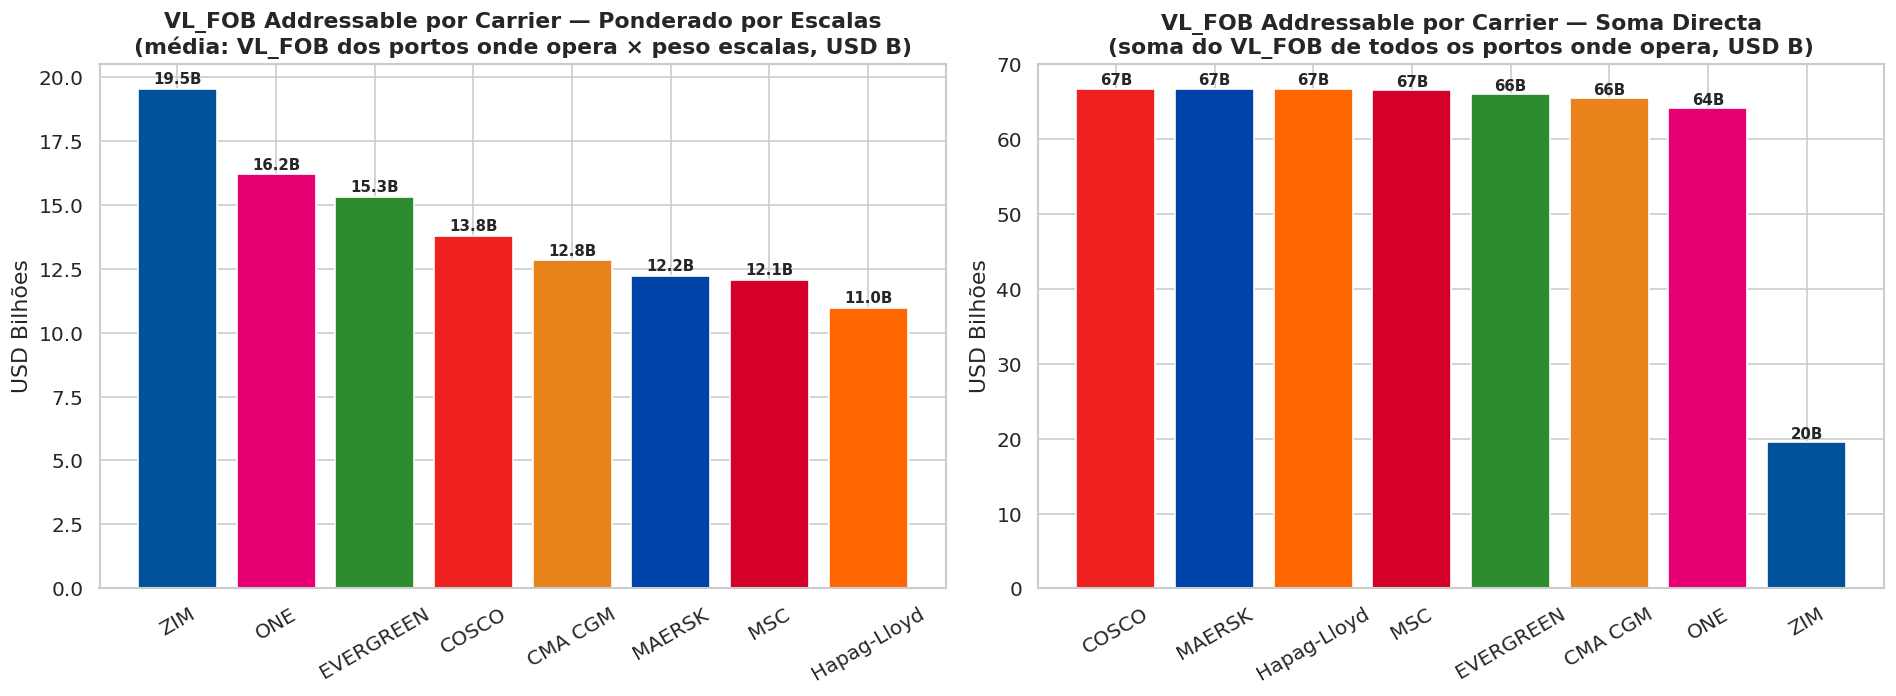

In [14]:
# Bar chart: ranking carriers por VL_FOB addressable
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ponderado por escalas
addr_sorted = addressable['VL_FOB_Addr_Pond_B'].sort_values(ascending=False)
colors_bar = [CARRIER_COLORS.get(c, '#888') for c in addr_sorted.index]
bars = axes[0].bar(addr_sorted.index, addr_sorted.values, color=colors_bar, edgecolor='white')
axes[0].set_title('VL_FOB Addressable por Carrier — Ponderado por Escalas\n'
                  '(média: VL_FOB dos portos onde opera × peso escalas, USD B)', fontweight='bold')
axes[0].set_ylabel('USD Bilhões')
axes[0].tick_params(axis='x', rotation=30)
for bar_obj, vv in zip(bars, addr_sorted.values):
    axes[0].text(bar_obj.get_x() + bar_obj.get_width()/2, vv + 0.2,
                 f'{vv:.1f}B', ha='center', fontsize=9, fontweight='bold')

# Soma directa dos portos onde opera
soma_sorted = addressable['VL_FOB_Addr_Soma_B'].sort_values(ascending=False)
colors_bar2 = [CARRIER_COLORS.get(c, '#888') for c in soma_sorted.index]
bars2 = axes[1].bar(soma_sorted.index, soma_sorted.values, color=colors_bar2, edgecolor='white')
axes[1].set_title('VL_FOB Addressable por Carrier — Soma Directa\n'
                  '(soma do VL_FOB de todos os portos onde opera, USD B)', fontweight='bold')
axes[1].set_ylabel('USD Bilhões')
axes[1].tick_params(axis='x', rotation=30)
for bar_obj, vv in zip(bars2, soma_sorted.values):
    axes[1].text(bar_obj.get_x() + bar_obj.get_width()/2, vv + 0.5,
                 f'{vv:.0f}B', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT / 'nb11_07_addressable_carrier.png', bbox_inches='tight')
plt.show()

### 4.2 Sobre-indexação: Carriers em Portos de Baixo Valor Relativo

% de escalas em portos com VL_FOB abaixo da mediana por carrier:
               Total_Esc  Esc_BaixoValor  Pct_BaixoValor
SHIPPING LINE                                           
Hapag-Lloyd          121              38            31.4
CMA CGM               84              25            29.8
COSCO                156              39            25.0
MAERSK               311              68            21.9
MSC                  169              34            20.1
ONE                   15               2            13.3
EVERGREEN            100               1             1.0
ZIM                    2               0             0.0


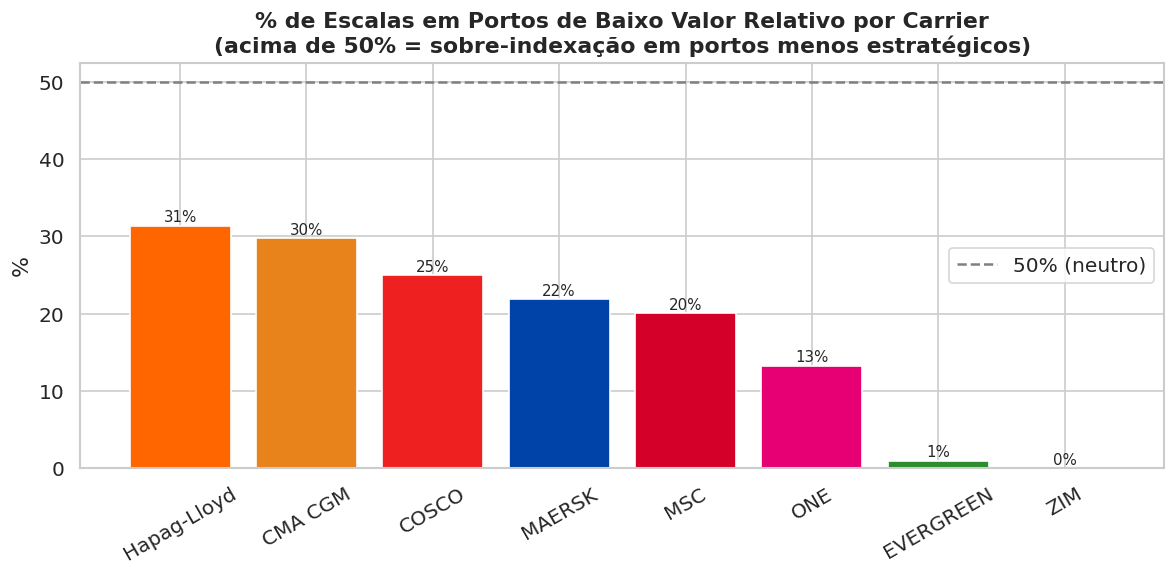

In [15]:
# Para cada carrier: qual % das suas escalas está em portos com VL_FOB abaixo da mediana?
porto_vlfob_rank = porto_vlfob.rank(pct=True).rename('VL_FOB_Pct_Rank')
carrier_porto = carrier_porto.join(porto_vlfob_rank, on='Porto_CS')
carrier_porto['VL_FOB_Pct_Rank'] = carrier_porto['VL_FOB_Pct_Rank'].fillna(0)

carrier_porto['Escalas_BaixoValor'] = carrier_porto['Escalas'] * (carrier_porto['VL_FOB_Pct_Rank'] < 0.5).astype(int)

sobreindex = (
    carrier_porto.groupby('SHIPPING LINE')
    .agg(Total_Esc=('Escalas','sum'), Esc_BaixoValor=('Escalas_BaixoValor','sum'))
)
sobreindex['Pct_BaixoValor'] = (sobreindex['Esc_BaixoValor'] / sobreindex['Total_Esc'] * 100).round(1)
sobreindex = sobreindex.sort_values('Pct_BaixoValor', ascending=False)

print('% de escalas em portos com VL_FOB abaixo da mediana por carrier:')
print(sobreindex.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors_si = [CARRIER_COLORS.get(c, '#888') for c in sobreindex.index]
ax.bar(sobreindex.index, sobreindex['Pct_BaixoValor'], color=colors_si, edgecolor='white')
ax.axhline(50, color='gray', linestyle='--', label='50% (neutro)')
ax.set_title('% de Escalas em Portos de Baixo Valor Relativo por Carrier\n'
             '(acima de 50% = sobre-indexação em portos menos estratégicos)', fontweight='bold')
ax.set_ylabel('%')
ax.legend()
ax.tick_params(axis='x', rotation=30)
for xi, vv in enumerate(sobreindex['Pct_BaixoValor']):
    ax.text(xi, vv + 0.5, f'{vv:.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'nb11_08_sobreindex_baixo_valor.png', bbox_inches='tight')
plt.show()

## 5. Análise Parte 4 — Gap de Cobertura

In [16]:
# Portos com alto VL_FOB mas poucos carriers com >= 5 escalas
carriers_regulares = (
    carrier_porto[carrier_porto['Escalas'] >= 5]
    .groupby('Porto_CS')['SHIPPING LINE']
    .nunique()
    .rename('Carriers_GE5_Esc')
)

gap_df = (
    porto_vlfob
    .to_frame()
    .join(carriers_regulares)
    .reset_index()
)
gap_df.columns = ['Porto','VL_FOB_2024','Carriers_GE5_Esc']
gap_df['Carriers_GE5_Esc'] = gap_df['Carriers_GE5_Esc'].fillna(0).astype(int)
gap_df['VL_FOB_B'] = (gap_df['VL_FOB_2024'] / 1e9).round(2)
gap_df = gap_df.sort_values('VL_FOB_B', ascending=False)

# Gap score: alto VL_FOB + poucos carriers regulares
gap_df['Gap_Score'] = (
    gap_df['VL_FOB_B'].rank(pct=True) - 
    gap_df['Carriers_GE5_Esc'].rank(pct=True)
).round(2)

print('=== Gap de Cobertura — Portos com Alto VL_FOB e Poucos Carriers Regulares ===')
print(gap_df[['Porto','VL_FOB_B','Carriers_GE5_Esc','Gap_Score']]
      .sort_values('Gap_Score', ascending=False).to_string(index=False))

print('\nPortos com Gap_Score > 0 = candidatos a oportunidade de entrada:')
opp = gap_df[gap_df['Gap_Score'] > 0].sort_values('Gap_Score', ascending=False)
print(opp[['Porto','VL_FOB_B','Carriers_GE5_Esc','Gap_Score']].to_string(index=False))

=== Gap de Cobertura — Portos com Alto VL_FOB e Poucos Carriers Regulares ===
         Porto  VL_FOB_B  Carriers_GE5_Esc  Gap_Score
        Santos     28.20                 6       0.22
    Rio Grande      1.28                 3       0.22
 Vila do Conde      0.26                 2       0.11
     Paranaguá      2.02                 5       0.06
Rio de Janeiro     12.21                 6       0.00
         Suape      0.35                 4       0.00
 Outros Portos     19.54                 7      -0.11
        Itajaí      2.79                 6      -0.11
         Pecém      0.12                 5      -0.39

Portos com Gap_Score > 0 = candidatos a oportunidade de entrada:
        Porto  VL_FOB_B  Carriers_GE5_Esc  Gap_Score
       Santos     28.20                 6       0.22
   Rio Grande      1.28                 3       0.22
Vila do Conde      0.26                 2       0.11
    Paranaguá      2.02                 5       0.06


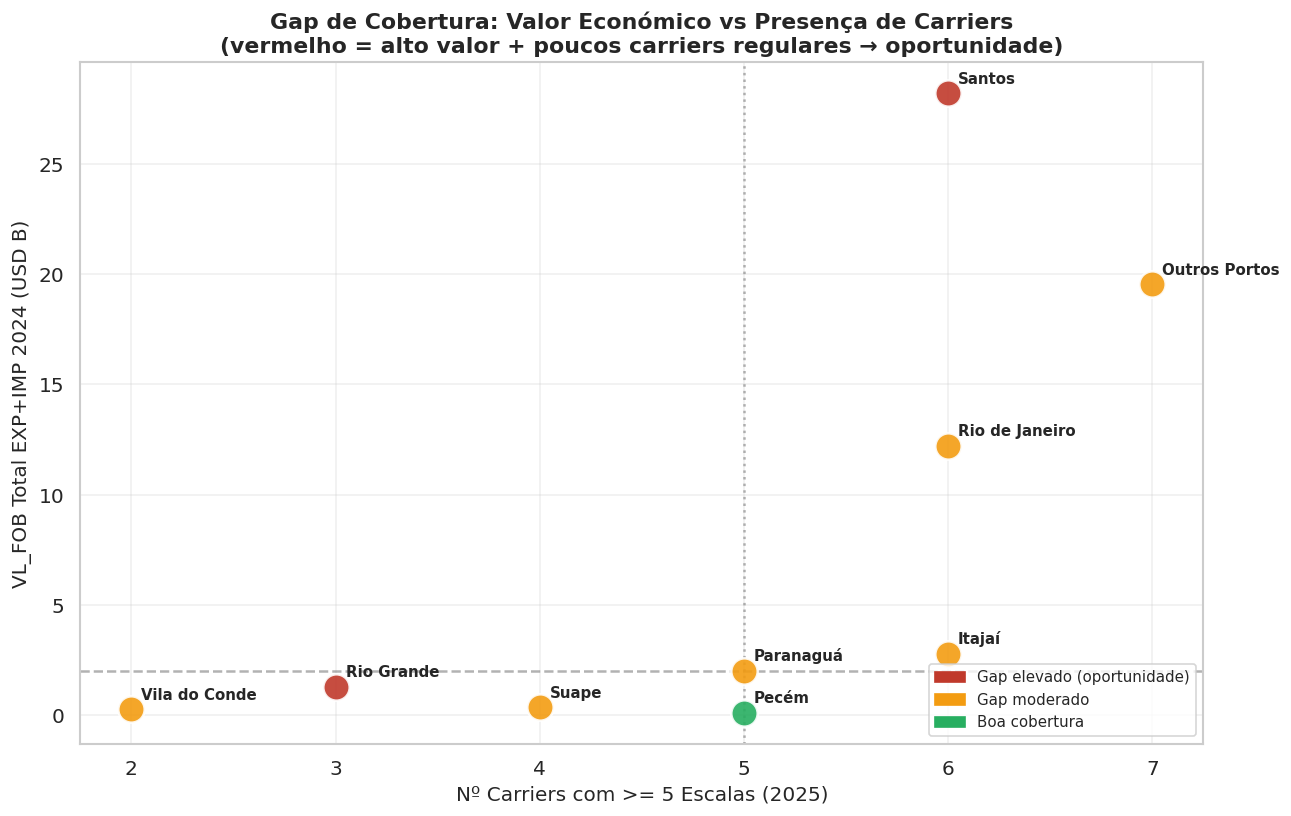

In [17]:
# Scatter: VL_FOB vs nº carriers regulares
fig, ax = plt.subplots(figsize=(11, 7))

for _, row in gap_df.iterrows():
    gap_col = '#c0392b' if row['Gap_Score'] > 0.2 else ('#27ae60' if row['Gap_Score'] < -0.2 else '#f39c12')
    ax.scatter(row['Carriers_GE5_Esc'], row['VL_FOB_B'], s=250,
               color=gap_col, alpha=0.9, edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(row['Porto'], xy=(row['Carriers_GE5_Esc'], row['VL_FOB_B']),
                xytext=(6, 6), textcoords='offset points', fontsize=9, fontweight='bold')

med_carriers = gap_df['Carriers_GE5_Esc'].median()
med_vl2 = gap_df['VL_FOB_B'].median()
ax.axvline(med_carriers, color='gray', linestyle=':', alpha=0.6, label=f'Mediana carriers: {med_carriers:.0f}')
ax.axhline(med_vl2, color='gray', linestyle='--', alpha=0.6, label=f'Mediana VL_FOB: {med_vl2:.1f}B')

handles = [
    mpatches.Patch(color='#c0392b', label='Gap elevado (oportunidade)'),
    mpatches.Patch(color='#f39c12', label='Gap moderado'),
    mpatches.Patch(color='#27ae60', label='Boa cobertura'),
]
ax.legend(handles=handles, loc='lower right', fontsize=9)
ax.set_xlabel('Nº Carriers com >= 5 Escalas (2025)', fontsize=12)
ax.set_ylabel('VL_FOB Total EXP+IMP 2024 (USD B)', fontsize=12)
ax.set_title('Gap de Cobertura: Valor Económico vs Presença de Carriers\n'
             '(vermelho = alto valor + poucos carriers regulares → oportunidade)', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'nb11_09_gap_cobertura.png', bbox_inches='tight')
plt.show()

## 6. Export CSV — Power BI

In [18]:
# 1. Tabela porto × ano × sentido
porto_all_export = full.groupby(['Porto','CO_ANO','Sentido']).agg(
    VL_FOB=('VL_FOB','sum'), KG=('KG_LIQUIDO','sum'), VL_FRETE=('VL_FRETE','sum')
).reset_index()
porto_all_export['USD_kg'] = (porto_all_export['VL_FOB'] / porto_all_export['KG'].replace(0,np.nan)).round(4)
porto_all_export.to_csv(PROC / 'comex_fob_por_porto_2023_2024.csv', index=False, encoding='utf-8-sig')

# 2. Corredores (porto × país × sentido × ano)
corredores_export = full.groupby(['Porto','Pais_Nome','CO_PAIS','Sentido','CO_ANO']).agg(
    VL_FOB=('VL_FOB','sum'), KG=('KG_LIQUIDO','sum')
).reset_index()
corredores_export.to_csv(PROC / 'comex_corredores_2023_2024.csv', index=False, encoding='utf-8-sig')

# 3. Addressable + gap
gap_carrier = addressable[['Total_Escalas','VL_FOB_Addr_Pond_B','VL_FOB_Addr_Soma_B']].join(
    sobreindex['Pct_BaixoValor']
)
gap_carrier.to_csv(PROC / 'comex_addressable_carrier_2025.csv', encoding='utf-8-sig')

# 4. Gap de cobertura
gap_df.to_csv(PROC / 'comex_gap_cobertura_porto_2025.csv', index=False, encoding='utf-8-sig')

print('Exportado: comex_fob_por_porto_2023_2024.csv')
print('Exportado: comex_corredores_2023_2024.csv')
print('Exportado: comex_addressable_carrier_2025.csv')
print('Exportado: comex_gap_cobertura_porto_2025.csv')

Exportado: comex_fob_por_porto_2023_2024.csv
Exportado: comex_corredores_2023_2024.csv
Exportado: comex_addressable_carrier_2025.csv
Exportado: comex_gap_cobertura_porto_2025.csv


## 7. Limitações Metodológicas

In [19]:
mapeados_pct_fob = (
    full[full['SG_UF_NCM'].isin(UF_PORTO.keys())]['VL_FOB'].sum() /
    full['VL_FOB'].sum() * 100
)

print('=' * 70)
print('LIMITAÇÕES METODOLÓGICAS')
print('=' * 70)
print()
print(f'1. MAPEAMENTO UF → PORTO: APROXIMAÇÃO')
print(f'   {mapeados_pct_fob:.1f}% do VL_FOB total está em estados com mapeamento directo.')
print(f'   {100-mapeados_pct_fob:.1f}% fica em "Outros Portos" — inclui MG (~USD 2.5B/ano),'
      f' BA, GO, MT.')
print(f'   MG exporta maioritariamente por Santos (aeronaves, joias, farmacêuticos).')
print(f'   Minas + SC têm múltiplos terminais activos — sem desagregação possível.')
print()
print(f'2. POSICIONAMENTO DE CARRIER É INDIRECTO')
print(f'   ComexStat não identifica o carrier. O VL_FOB addressable é uma estimativa')
print(f'   do potencial de mercado do porto — não do valor efectivamente transportado')
print(f'   por cada carrier. Um carrier pode ter escalas num porto sem capturar')
print(f'   a carga de alto valor (ex: operar feeder em porto principal).')
print()
print(f'3. FILTRO NCM: APROXIMAÇÃO')
print(f'   Capítulos 10,12,23,25,26,27,72,73 excluídos como granéis não contentorizáveis.')
print(f'   Alguns NCM excluídos têm componente contentorizado (ex: cereais embalados,')
print(f'   produtos siderúrgicos acabados). O sentido inverso também ocorre:')
print(f'   alguns capítulos mantidos incluem produtos a granel.')
print()
print(f'4. DESFASAGEM TEMPORAL')
print(f'   ComexStat: 2023–2024. Escalas carriers: 2025.')
print(f'   Assume-se padrão de comércio estável entre períodos.')
print(f'   Variações estruturais (ex: reconfiguração de rotas, novos serviços)')
print(f'   não são capturadas.')
print()
print(f'5. VL_FOB: VALOR NA ORIGEM')
print(f'   Não inclui frete marítimo nem seguro. Para importações, VL_CIF')
print(f'   (= VL_FOB + VL_FRETE + VL_SEGURO) é o valor relevante para o carrier.')
print(f'   VL_FRETE está disponível no ComexStat IMP e foi exportado nos CSVs.')
print('=' * 70)

LIMITAÇÕES METODOLÓGICAS

1. MAPEAMENTO UF → PORTO: APROXIMAÇÃO
   70.7% do VL_FOB total está em estados com mapeamento directo.
   29.3% fica em "Outros Portos" — inclui MG (~USD 2.5B/ano), BA, GO, MT.
   MG exporta maioritariamente por Santos (aeronaves, joias, farmacêuticos).
   Minas + SC têm múltiplos terminais activos — sem desagregação possível.

2. POSICIONAMENTO DE CARRIER É INDIRECTO
   ComexStat não identifica o carrier. O VL_FOB addressable é uma estimativa
   do potencial de mercado do porto — não do valor efectivamente transportado
   por cada carrier. Um carrier pode ter escalas num porto sem capturar
   a carga de alto valor (ex: operar feeder em porto principal).

3. FILTRO NCM: APROXIMAÇÃO
   Capítulos 10,12,23,25,26,27,72,73 excluídos como granéis não contentorizáveis.
   Alguns NCM excluídos têm componente contentorizado (ex: cereais embalados,
   produtos siderúrgicos acabados). O sentido inverso também ocorre:
   alguns capítulos mantidos incluem produtos a granel